# Toy state space model from *Mamba*

This notebook gives a **very small, runnable toy example** inspired by the paper's state space model (SSM) recurrence:

\[
h_t = ar{A} h_{t-1} + ar{B} x_t,\qquad y_t = C h_t
\]

and a **selective / gated** variant motivated by the paper's discussion of input-dependent dynamics.

The goal here is intuition, not performance.

## 1) Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2) A tiny linear time-invariant (LTI) SSM

This mirrors the paper's basic SSM view: a hidden state is updated recursively from the previous state and the current input.

We'll use a **scalar** hidden state for simplicity:

\[
h_t = a h_{t-1} + b x_t,\qquad y_t = c h_t
\]

Interpretation:
- `a` controls memory / decay
- `b` controls how much input enters the state
- `c` reads the state out to the output

In [2]:
def run_lti_ssm(x, a=0.9, b=1.0, c=1.0, h0=0.0):
    h = h0
    hs, ys = [], []
    for xt in x:
        h = a * h + b * xt
        y = c * h
        hs.append(h)
        ys.append(y)
    return np.array(hs), np.array(ys)

## 3) Feed a toy sequence

We'll make a sequence with a few important spikes and a lot of zeros/noise in between.

In [3]:
x = np.array([0, 0, 2, 0, 0, 0, -1, 0, 0, 3, 0, 0], dtype=float)
hs_lti, ys_lti = run_lti_ssm(x, a=0.8, b=0.7, c=1.0)

print("input x =", x)
print("hidden state h =", np.round(hs_lti, 3))
print("output y =", np.round(ys_lti, 3))

input x = [ 0.  0.  2.  0.  0.  0. -1.  0.  0.  3.  0.  0.]
hidden state h = [ 0.     0.     1.4    1.12   0.896  0.717 -0.127 -0.101 -0.081  2.035
  1.628  1.303]
output y = [ 0.     0.     1.4    1.12   0.896  0.717 -0.127 -0.101 -0.081  2.035
  1.628  1.303]


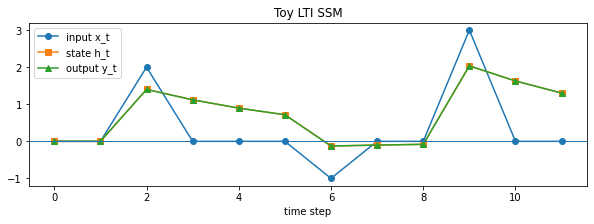

In [4]:
t = np.arange(len(x))

plt.figure(figsize=(10, 3))
plt.plot(t, x, marker='o', label='input x_t')
plt.plot(t, hs_lti, marker='s', label='state h_t')
plt.plot(t, ys_lti, marker='^', label='output y_t')
plt.axhline(0, linewidth=1)
plt.title("Toy LTI SSM")
plt.xlabel("time step")
plt.legend()
plt.show()

## 4) A toy **selective** SSM / gated update

One key idea in the paper is to make some dynamics **input-dependent**, instead of fixed across all time steps.

A very simple scalar toy version is:

\[
g_t = \sigma(k(x_t - 	heta))
\]
\[
h_t = (1-g_t) h_{t-1} + g_t x_t
\]

This is the scalar gated form discussed in the paper when the state dimension is 1.

Intuition:
- when `g_t` is small, the model mostly **keeps old state**
- when `g_t` is large, the model **updates / resets toward current input**

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def run_selective_ssm(x, k=4.0, theta=0.5, h0=0.0):
    h = h0
    hs, gs = [], []
    for xt in x:
        g = sigmoid(k * (abs(xt) - theta))   # open gate for "important" tokens
        h = (1 - g) * h + g * xt
        hs.append(h)
        gs.append(g)
    return np.array(hs), np.array(gs)

## 5) Compare LTI vs selective behavior

We'll use a sequence with lots of tiny distractors and a few large values.

In [6]:
x2 = np.array([0.05, 0.02, 1.5, 0.03, -0.02, 0.01, 0.0, 2.0, 0.04, 0.01, -1.8, 0.02])

hs_lti2, _ = run_lti_ssm(x2, a=0.9, b=1.0, c=1.0)
hs_sel2, gs2 = run_selective_ssm(x2, k=8.0, theta=0.2)

print("x2       =", np.round(x2, 3))
print("LTI h_t  =", np.round(hs_lti2, 3))
print("gate g_t =", np.round(gs2, 3))
print("SEL h_t  =", np.round(hs_sel2, 3))

x2       = [ 0.05  0.02  1.5   0.03 -0.02  0.01  0.    2.    0.04  0.01 -1.8   0.02]
LTI h_t  = [0.05  0.065 1.558 1.433 1.269 1.152 1.037 2.933 2.68  2.422 0.38  0.362]
gate g_t = [0.231 0.192 1.    0.204 0.192 0.179 0.168 1.    0.218 0.179 1.    0.192]
SEL h_t  = [ 0.012  0.013  1.5    1.2    0.966  0.795  0.661  2.     1.574  1.293
 -1.8   -1.451]


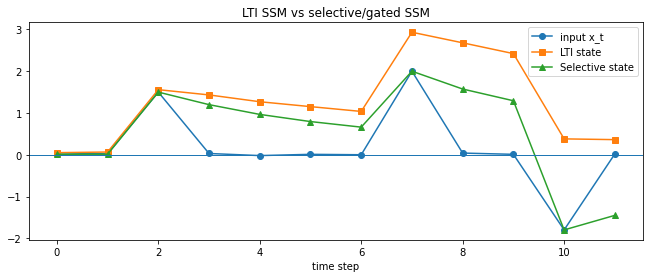

In [7]:
t = np.arange(len(x2))

plt.figure(figsize=(11, 4))
plt.plot(t, x2, marker='o', label='input x_t')
plt.plot(t, hs_lti2, marker='s', label='LTI state')
plt.plot(t, hs_sel2, marker='^', label='Selective state')
plt.axhline(0, linewidth=1)
plt.title("LTI SSM vs selective/gated SSM")
plt.xlabel("time step")
plt.legend()
plt.show()

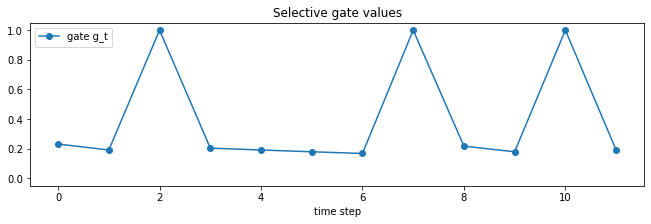

In [8]:
plt.figure(figsize=(11, 3))
plt.plot(t, gs2, marker='o', label='gate g_t')
plt.ylim(-0.05, 1.05)
plt.title("Selective gate values")
plt.xlabel("time step")
plt.legend()
plt.show()

## 6) Why this matches the paper's intuition

Very roughly:

- **LTI SSM**: same update rule at every step  
- **Selective SSM**: update strength depends on the current token/input

So the selective version can ignore tiny distractors and react strongly to salient inputs.

That is the same high-level point emphasized in the paper: fixed dynamics are limited for content-based reasoning, while input-dependent updates let the model selectively remember or forget.

## 7) Optional: a tiny 2D state example

Below is a slightly more "matrix-shaped" SSM:

\[
h_t = A h_{t-1} + B x_t,\qquad y_t = C h_t
\]

where now \(h_t \in \mathbb{R}^2\).

In [9]:
def run_matrix_ssm(x, A, B, C, h0=None):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float).reshape(-1, 1)
    C = np.asarray(C, dtype=float).reshape(1, -1)
    h = np.zeros(A.shape[0]) if h0 is None else np.asarray(h0, dtype=float)

    hs, ys = [], []
    for xt in x:
        h = A @ h + (B[:, 0] * xt)
        y = (C @ h.reshape(-1, 1))[0, 0]
        hs.append(h.copy())
        ys.append(y)
    return np.array(hs), np.array(ys)

A = np.array([[0.85, 0.10],
              [0.00, 0.60]])
B = np.array([[1.0],
              [0.3]])
C = np.array([[1.0, -0.5]])

x3 = np.array([0, 1, 0, 0, 2, 0, -1, 0], dtype=float)
hs3, ys3 = run_matrix_ssm(x3, A, B, C)

print("states:")
print(np.round(hs3, 3))
print("outputs:")
print(np.round(ys3, 3))

states:
[[ 0.     0.   ]
 [ 1.     0.3  ]
 [ 0.88   0.18 ]
 [ 0.766  0.108]
 [ 2.662  0.665]
 [ 2.329  0.399]
 [ 1.02  -0.061]
 [ 0.861 -0.036]]
outputs:
[0.    0.85  0.79  0.712 2.33  2.13  1.05  0.879]


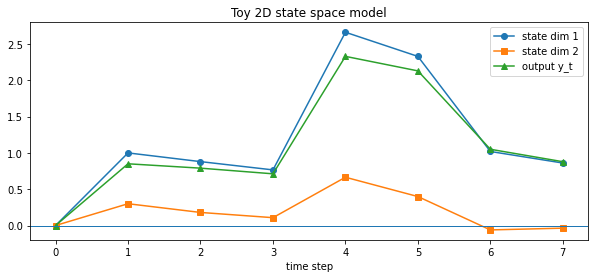

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(hs3[:, 0], marker='o', label='state dim 1')
plt.plot(hs3[:, 1], marker='s', label='state dim 2')
plt.plot(ys3, marker='^', label='output y_t')
plt.axhline(0, linewidth=1)
plt.title("Toy 2D state space model")
plt.xlabel("time step")
plt.legend()
plt.show()

## 8) Takeaway

For a **quick mental model**:

- a state space model keeps a compressed memory `h_t`
- the simplest version uses a fixed linear recurrence
- the Mamba paper's key twist is making parts of that update **depend on the input**, so the model can selectively keep, forget, or reset information

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def selective_state_update(x_t, h_prev, k=6.0, theta=0.45):
    """
    Scalar selective SSM update:
        g_t = sigmoid(k * (|x_t| - theta))
        h_t = (1 - g_t) * h_{t-1} + g_t * x_t

    Here:
      - x_t is a toy "importance/value" for the current token
      - h_t is the running state
      - g_t is the selective gate
    """
    g_t = sigmoid(k * (abs(x_t) - theta))
    h_t = (1 - g_t) * h_prev + g_t * x_t
    y_t = h_t   # toy choice: output = state
    return h_t, y_t, g_t

# A toy sentence
tokens = ["um", "I", "left", "my", "keys", "on", "the", "blue", "table", "um", "yesterday"]

# Hand-crafted token values:
# low magnitude -> likely ignored
# high magnitude -> likely selected into state
token_values = {
    "um": 0.05,
    "I": 0.20,
    "left": 0.45,
    "my": 0.15,
    "keys": 0.95,
    "on": 0.10,
    "the": 0.05,
    "blue": 0.75,
    "table": 0.90,
    "yesterday": 0.85,
}

x = np.array([token_values[t] for t in tokens], dtype=float)

h = 0.0
rows = []

for t, (tok, x_t) in enumerate(zip(tokens, x)):
    h, y, g = selective_state_update(x_t, h, k=6.0, theta=0.45)
    rows.append((t, tok, x_t, g, h, y))

print(f"{'t':>2}  {'token':<10} {'x_t':>6} {'gate g_t':>10} {'state h_t':>10} {'output y_t':>11}")
print("-" * 58)
for t, tok, x_t, g, h, y in rows:
    print(f"{t:>2}  {tok:<10} {x_t:>6.2f} {g:>10.3f} {h:>10.3f} {y:>11.3f}")

 t  token         x_t   gate g_t  state h_t  output y_t
----------------------------------------------------------
 0  um           0.05      0.083      0.004       0.004
 1  I            0.20      0.182      0.040       0.040
 2  left         0.45      0.500      0.245       0.245
 3  my           0.15      0.142      0.231       0.231
 4  keys         0.95      0.953      0.916       0.916
 5  on           0.10      0.109      0.827       0.827
 6  the          0.05      0.083      0.762       0.762
 7  blue         0.75      0.858      0.752       0.752
 8  table        0.90      0.937      0.891       0.891
 9  um           0.05      0.083      0.821       0.821
10  yesterday    0.85      0.917      0.848       0.848


In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def selective_ssm_vector(tokens, embeddings, importance, k=6.0, theta=0.45):
    """
    Vector-valued hidden state, scalar input-dependent gate.
    h_t = (1 - g_t) h_{t-1} + g_t x_t
    y_t = h_t
    """
    h = np.zeros(2)
    history = []

    for tok in tokens:
        x_t = np.array(embeddings[tok], dtype=float)
        s_t = importance[tok]               # scalar importance score
        g_t = sigmoid(k * (s_t - theta))    # input-dependent selectivity
        h = (1 - g_t) * h + g_t * x_t
        y = h.copy()
        history.append({
            "token": tok,
            "importance": s_t,
            "gate": g_t,
            "x_t": x_t,
            "h_t": h.copy(),
            "y_t": y.copy(),
        })
    return history

tokens = ["um", "I", "left", "my", "keys", "on", "the", "blue", "table", "um", "yesterday"]

# 2D toy embeddings:
# dim 0 ~ "object/location" signal
# dim 1 ~ "time/person/action" signal
embeddings = {
    "um":        [0.0, 0.0],
    "I":         [0.0, 0.3],
    "left":      [0.2, 0.4],
    "my":        [0.0, 0.1],
    "keys":      [1.0, 0.0],
    "on":        [0.1, 0.0],
    "the":       [0.0, 0.0],
    "blue":      [0.7, 0.0],
    "table":     [0.9, 0.0],
    "yesterday": [0.0, 0.9],
}

importance = {
    "um": 0.05,
    "I": 0.20,
    "left": 0.45,
    "my": 0.10,
    "keys": 0.95,
    "on": 0.10,
    "the": 0.05,
    "blue": 0.70,
    "table": 0.90,
    "yesterday": 0.85,
}

history = selective_ssm_vector(tokens, embeddings, importance)

print(f"{'token':<10} {'imp':>5} {'gate':>7} {'x_t':>18} {'h_t / y_t':>24}")
print("-" * 72)
for row in history:
    tok = row["token"]
    imp = row["importance"]
    gate = row["gate"]
    x_t = np.round(row["x_t"], 3)
    h_t = np.round(row["h_t"], 3)
    print(f"{tok:<10} {imp:>5.2f} {gate:>7.3f} {str(x_t):>18} {str(h_t):>24}")

token        imp    gate                x_t                h_t / y_t
------------------------------------------------------------------------
um          0.05   0.083            [0. 0.]                  [0. 0.]
I           0.20   0.182          [0.  0.3]            [0.    0.055]
left        0.45   0.500          [0.2 0.4]            [0.1   0.227]
my          0.10   0.109          [0.  0.1]            [0.089 0.213]
keys        0.95   0.953            [1. 0.]            [0.957 0.01 ]
on          0.10   0.109          [0.1 0. ]            [0.863 0.009]
the         0.05   0.083            [0. 0.]            [0.792 0.008]
blue        0.70   0.818          [0.7 0. ]            [0.717 0.002]
table       0.90   0.937          [0.9 0. ]            [0.888 0.   ]
um          0.05   0.083            [0. 0.]            [0.815 0.   ]
yesterday   0.85   0.917          [0.  0.9]            [0.068 0.825]


In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --------------------------------------------------
# 1. LTI model: same gate for every token
# --------------------------------------------------
def run_lti_ssm(x, alpha=0.8, beta=0.2, h0=0.0):
    """
    h_t = alpha * h_{t-1} + beta * x_t
    y_t = h_t
    """
    h = h0
    ys = []
    for xt in x:
        h = alpha * h + beta * xt
        y = h
        ys.append(y)
    return np.array(ys)

# --------------------------------------------------
# 2. Selective model: gate depends on input
# --------------------------------------------------
def run_selective_ssm(x, k=8.0, theta=0.45, h0=0.0):
    """
    g_t = sigmoid(k * (|x_t| - theta))
    h_t = (1 - g_t) h_{t-1} + g_t x_t
    y_t = h_t
    """
    h = h0
    ys, gs = [], []
    for xt in x:
        g = sigmoid(k * (abs(xt) - theta))
        h = (1 - g) * h + g * xt
        y = h
        ys.append(y)
        gs.append(g)
    return np.array(ys), np.array(gs)

# --------------------------------------------------
# 3. Toy "language" sequence
# --------------------------------------------------
tokens = ["um", "I", "left", "my", "keys", "on", "the", "blue", "table", "um", "yesterday"]

# scalar token values
token_values = {
    "um": 0.05,
    "I": 0.20,
    "left": 0.45,
    "my": 0.10,
    "keys": 0.95,
    "on": 0.10,
    "the": 0.05,
    "blue": 0.75,
    "table": 0.90,
    "yesterday": 0.85,
}

x = np.array([token_values[t] for t in tokens], dtype=float)

y_lti = run_lti_ssm(x, alpha=0.8, beta=0.2)
y_sel, g_sel = run_selective_ssm(x, k=8.0, theta=0.45)

# --------------------------------------------------
# 4. Print comparison table
# --------------------------------------------------
print(f"{'t':>2} {'token':<10} {'x_t':>6} {'y_lti':>8} {'y_sel':>8} {'gate':>8} {'selected?':>10}")
print("-" * 62)
for i, tok in enumerate(tokens):
    selected = "YES" if g_sel[i] > 0.5 else "no"
    print(f"{i:>2} {tok:<10} {x[i]:>6.2f} {y_lti[i]:>8.3f} {y_sel[i]:>8.3f} {g_sel[i]:>8.3f} {selected:>10}")

 t token         x_t    y_lti    y_sel     gate  selected?
--------------------------------------------------------------
 0 um           0.05    0.010    0.002    0.039         no
 1 I            0.20    0.048    0.026    0.119         no
 2 left         0.45    0.128    0.238    0.500         no
 3 my           0.10    0.123    0.230    0.057         no
 4 keys         0.95    0.288    0.937    0.982        YES
 5 on           0.10    0.251    0.889    0.057         no
 6 the          0.05    0.210    0.856    0.039         no
 7 blue         0.75    0.318    0.759    0.917        YES
 8 table        0.90    0.435    0.896    0.973        YES
 9 um           0.05    0.358    0.863    0.039         no
10 yesterday    0.85    0.456    0.851    0.961        YES
